# Практическая работа №3

In [274]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import optuna

In [275]:
data = pd.read_csv("data_sets/Data_for_UCI_named.csv")

In [276]:
data

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959,3.080,8.381,9.781,3.763,-0.783,-1.257,-1.723,0.650,0.860,0.887,0.958,0.055,unstable
1,9.304,4.903,3.048,1.369,5.068,-1.940,-1.873,-1.255,0.413,0.862,0.562,0.782,-0.006,stable
2,8.972,8.848,3.046,1.215,3.405,-1.207,-1.277,-0.920,0.163,0.767,0.839,0.110,0.003,unstable
3,0.716,7.670,4.487,2.341,3.964,-1.027,-1.939,-0.997,0.446,0.977,0.929,0.363,0.029,unstable
4,3.134,7.609,4.944,9.858,3.526,-1.126,-1.846,-0.554,0.797,0.455,0.657,0.821,0.050,unstable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2.930,9.488,2.377,6.188,3.343,-0.658,-1.449,-1.236,0.602,0.780,0.814,0.608,0.024,unstable
9996,3.392,1.275,2.955,6.895,4.350,-1.664,-0.952,-1.733,0.502,0.567,0.286,0.366,-0.026,stable
9997,2.364,2.842,8.776,1.009,4.300,-1.381,-0.944,-1.975,0.488,0.987,0.149,0.146,-0.032,stable
9998,9.632,3.994,2.757,7.821,2.515,-0.966,-0.650,-0.899,0.365,0.588,0.889,0.818,0.038,unstable


In [277]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


### Статистический анализ

In [278]:
data.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,5.250,5.250,5.250,5.250,3.750,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.016
std,2.743,2.743,2.743,2.743,0.752,0.433,0.433,0.433,0.274,0.274,0.274,0.274,0.037
min,0.501,0.500,0.501,0.500,1.583,-2.000,-2.000,-2.000,0.050,0.050,0.050,0.050,-0.081
25%,2.875,2.875,2.876,2.875,3.218,-1.625,-1.625,-1.625,0.288,0.288,0.288,0.287,-0.016
50%,5.250,5.250,5.250,5.250,3.751,-1.250,-1.250,-1.250,0.525,0.525,0.525,0.525,0.017
75%,7.625,7.625,7.625,7.625,4.282,-0.875,-0.875,-0.875,0.762,0.762,0.762,0.762,0.045
max,9.999,10.000,9.999,9.999,5.864,-0.500,-0.500,-0.500,1.000,1.000,1.000,1.000,0.109


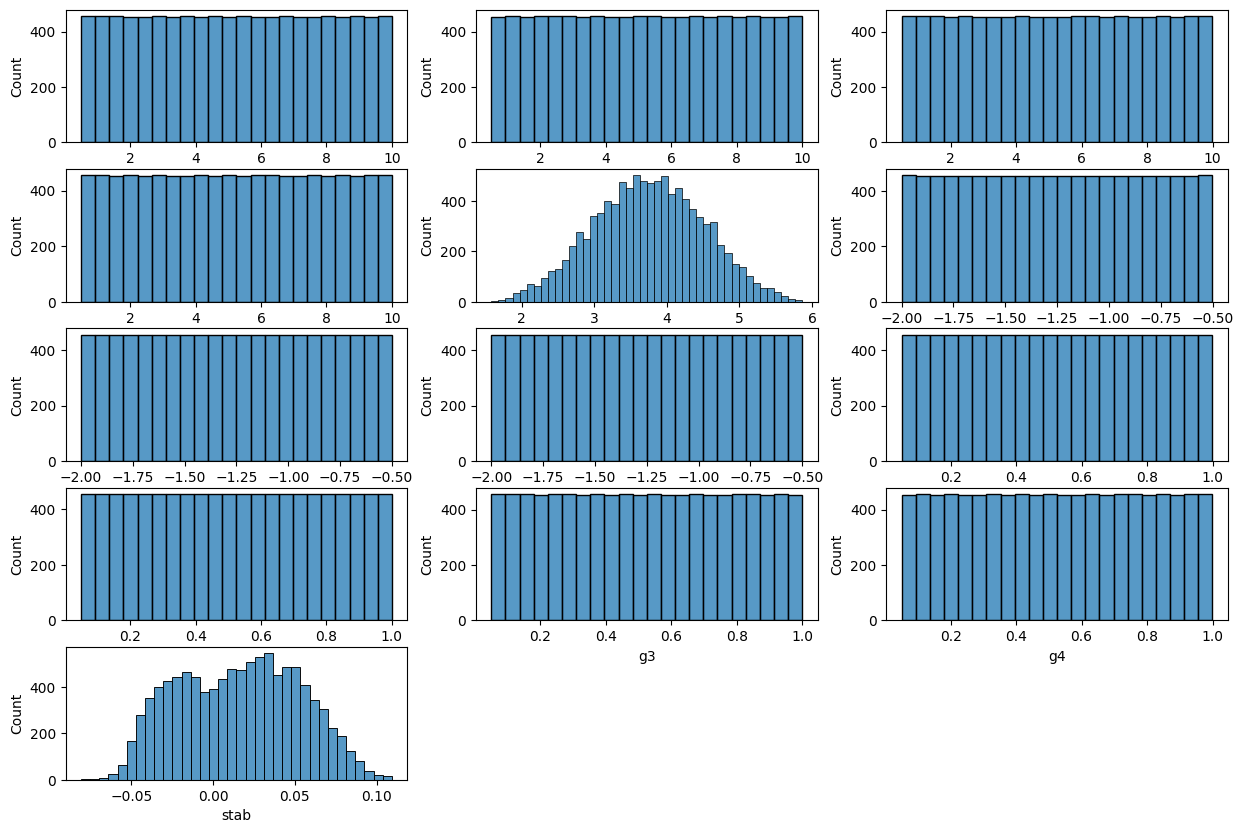

In [279]:
numeric_columns = data.select_dtypes(include=['number']).columns

fig, ax = plt.subplots(5, 3, figsize=(15, 10))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.histplot(data=data[column], ax=ax)

axes[-1].set_visible(False)
axes[-2].set_visible(False)

<Axes: >

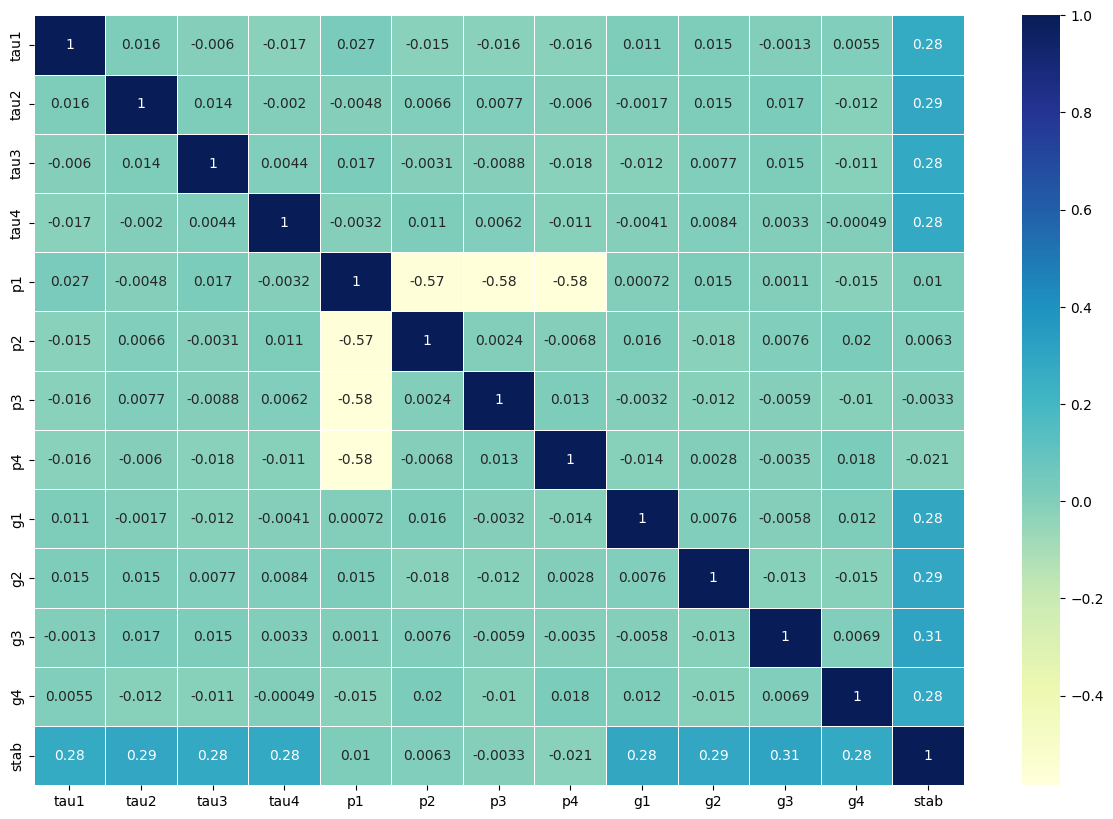

In [280]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only = True), annot=True, cmap="YlGnBu", linewidths=.5 )

### Анализ выбросов

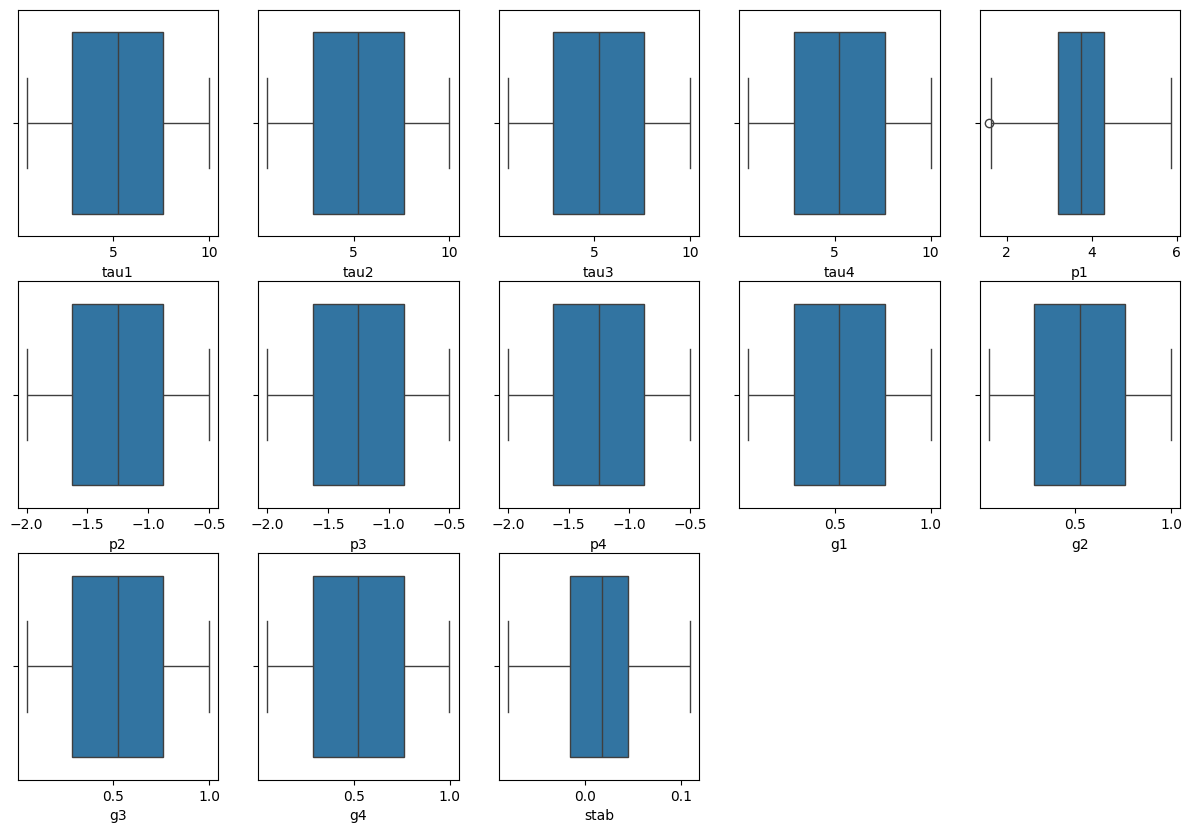

In [281]:
numeric_columns = data.select_dtypes(include=['number']).columns
# plt.subplots_adjust(hspace=0.5)
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
axes = ax.flatten()
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(x = data[column], ax=ax)

axes[-1].set_visible(False)
axes[-2].set_visible(False)

<Axes: ylabel='p1'>

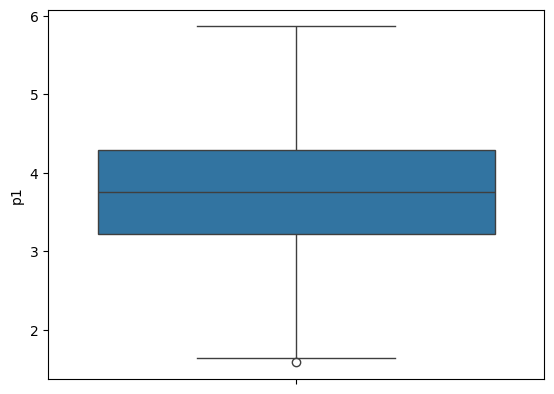

In [282]:
sns.boxplot(data["p1"])

In [283]:
iqr = data["p1"].quantile(0.75) - data["p1"].quantile(0.25)

data[data["p1"] <= 1.5 * iqr]

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
6273,6.698,7.861,9.333,2.434,1.583,-0.504,-0.572,-0.507,0.642,0.868,0.494,0.411,0.057,unstable


### Кодирование признаков

In [284]:
data["stabf"] = data["stabf"].map({"stable": 1, "unstable": 0})

In [285]:
vif_data = pd.DataFrame()

vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

vif_data["Features"] = data.columns

vif_data

C:\Users\stwz13\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Features
0,4.594,tau1
1,4.560,tau2
2,4.580,tau3
3,4.518,tau4
4,inf,p1
5,inf,p2
6,inf,p3
7,inf,p4
8,4.632,g1
9,4.675,g2


### Обучение модели регрессии

In [286]:
def input_into_the_tables(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          train_and_test_comparing):
    sk_learn_test_metrics = [r2_score(y_test, predict_on_test_y), mean_squared_error(y_test, predict_on_test_y), root_mean_squared_error(y_test, predict_on_test_y), mean_absolute_error(y_test, predict_on_test_y), mean_absolute_percentage_error(y_test, predict_on_test_y)]

    sk_learn_train_metrics = [r2_score(y_train, predict_on_train_y), mean_squared_error(y_train, predict_on_train_y), root_mean_squared_error(y_train, predict_on_train_y), mean_absolute_error(y_train, predict_on_train_y), mean_absolute_percentage_error(y_train, predict_on_train_y)]

    train_and_test_comparing.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics

In [287]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
pd.options.display.float_format = '{:.3f}'.format
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [288]:
X = data.drop("stab", axis=1)
y = data["stab"]

In [289]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [290]:
model = LinearRegression()
model.fit(X_train, y_train)
model.coef_

array([ 1.94976172e-03,  2.05320718e-03,  2.09176638e-03,  2.07068464e-03,
       -1.09511850e-04, -8.78845238e-05,  2.32999259e-04, -3.56028854e-05,
        2.36754600e-02,  2.36562747e-02,  2.42434101e-02,  2.34286974e-02,
       -4.07095370e-02])

In [291]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

input_into_the_tables(    "Linear Regression",
                          train_predict, y_train,
                          test_predict, y_test,
                          train_and_test_comparing)

train_and_test_comparing.loc["Linear Regression"]

Train Data  R2      0.817
            MSE     0.000
            RMSE    0.016
            MAE     0.013
            MAPE   12.679
Test Data   R2      0.809
            MSE     0.000
            RMSE    0.016
            MAE     0.013
            MAPE    5.087
Name: Linear Regression, dtype: float64

In [292]:
def find_best_regularization_params(
    X_train, y_train,
    cv=5,
    n_iter_random=40,
    n_trials_optuna=50,
    random_state=42
):
    models_config = [
        {
            "name": "Lasso",
            "class": Lasso,
            "random_params": {"alpha": np.logspace(-5, 4, 60)},
            "grid_params": {"alpha": np.logspace(-5, 4, 25)},
            "fixed": {"random_state": random_state}
        },
        {
            "name": "Ridge",
            "class": Ridge,
            "random_params": {"alpha": np.logspace(-5, 6, 70)},
            "grid_params": {"alpha": np.logspace(-5, 6, 30)},
            "fixed": {"random_state": random_state}
        },
        {
            "name": "ElasticNet",
            "class": ElasticNet,
            "random_params": {
                "alpha": np.logspace(-5, 3, 40),
                "l1_ratio": np.linspace(0.05, 0.95, 19)
            },
            "grid_params": {
                "alpha": np.logspace(-5, 2, 18),
                "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
            },
            "fixed": {"random_state": random_state}
        }
    ]

    results = {}

    for cfg in models_config:
        name = cfg["name"]
        Model = cfg["class"]
        results[name] = {}

        rs = RandomizedSearchCV(
            Model(**cfg["fixed"]),
            param_distributions=cfg["random_params"],
            n_iter=n_iter_random,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
            random_state=random_state
        )
        rs.fit(X_train, y_train)
        results[name]["RandomizedSearchCV"] = rs.best_params_


        gs = GridSearchCV(
            Model(**cfg["fixed"]),
            param_grid=cfg["grid_params"],
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )
        gs.fit(X_train, y_train)
        results[name]["GridSearchCV"] = gs.best_params_


        def objective(trial):
            if name == "ElasticNet":
                alpha = trial.suggest_float("alpha", 1e-6, 1e5, log=True)
                l1_ratio = trial.suggest_float("l1_ratio", 0.01, 0.99)
                mdl = Model(alpha=alpha, l1_ratio=l1_ratio, **cfg["fixed"])
            else:
                alpha = trial.suggest_float("alpha", 1e-6, 1e6, log=True)
                mdl = Model(alpha=alpha, **cfg["fixed"])
            mdl.fit(X_train, y_train)

            return mdl.score(X_test, y_test)

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials_optuna, show_progress_bar=False)
        results[name]["Optuna"] = study.best_params

    return results

In [293]:
best_params = find_best_regularization_params(X_train, y_train)
best_params["Lasso"]

[I 2026-03-05 08:44:42,580] A new study created in memory with name: no-name-848c752e-ebfc-476b-9c31-f4381598c76d
[I 2026-03-05 08:44:42,591] Trial 0 finished with value: 0.8091126393904317 and parameters: {'alpha': 2.4091847173490048e-06}. Best is trial 0 with value: 0.8091126393904317.
[I 2026-03-05 08:44:42,591] Trial 1 finished with value: -0.0017224034769722785 and parameters: {'alpha': 28886.65079905354}. Best is trial 0 with value: 0.8091126393904317.
[I 2026-03-05 08:44:42,591] Trial 2 finished with value: 0.0805336335269099 and parameters: {'alpha': 0.024715019735876507}. Best is trial 0 with value: 0.8091126393904317.
[I 2026-03-05 08:44:42,607] Trial 3 finished with value: -0.0017224034769722785 and parameters: {'alpha': 0.661754828021459}. Best is trial 0 with value: 0.8091126393904317.
[I 2026-03-05 08:44:42,607] Trial 4 finished with value: 0.7871208027236711 and parameters: {'alpha': 0.0007307158836663568}. Best is trial 0 with value: 0.8091126393904317.
[I 2026-03-05 08

{'RandomizedSearchCV': {'alpha': np.float64(2.868316813342009e-05)},
 'GridSearchCV': {'alpha': np.float64(2.3713737056616554e-05)},
 'Optuna': {'alpha': 5.07999796966946e-06}}

Оптимальные параметры, полученные тремя различными способами, примерно одинаковы. Можно выбрать любой из них, например, оптимальный параметр, полученный с помощью RandomizeSearch.

In [294]:
lasso_best_param = best_params["Lasso"]["RandomizedSearchCV"]["alpha"]
lasso_best_param

np.float64(2.868316813342009e-05)

In [295]:
lasso_reg_model = Lasso(alpha=lasso_best_param)
lasso_reg_model.fit(X_train, y_train)

lasso_train_predict = lasso_reg_model.predict(X_train)
lasso_test_predict = lasso_reg_model.predict(X_test)

print(model.coef_, lasso_reg_model.coef_)

[ 1.94976172e-03  2.05320718e-03  2.09176638e-03  2.07068464e-03
 -1.09511850e-04 -8.78845238e-05  2.32999259e-04 -3.56028854e-05
  2.36754600e-02  2.36562747e-02  2.42434101e-02  2.34286974e-02
 -4.07095370e-02] [ 1.94158165e-03  2.04514493e-03  2.08322054e-03  2.06132844e-03
 -5.63255260e-05 -0.00000000e+00  1.23226047e-04  0.00000000e+00
  2.32517463e-02  2.32254326e-02  2.38073890e-02  2.29964197e-02
 -4.08455775e-02]


С применением L1 регуляризации значения весов практически не изменились.

In [296]:
input_into_the_tables("Linear Regression with Lasso regularization",
                      lasso_train_predict, y_train,
                      lasso_test_predict, y_test,
                      train_and_test_comparing)

train_and_test_comparing.loc["Linear Regression with Lasso regularization"]

Train Data  R2      0.817
            MSE     0.000
            RMSE    0.016
            MAE     0.013
            MAPE   12.799
Test Data   R2      0.809
            MSE     0.000
            RMSE    0.016
            MAE     0.013
            MAPE    5.141
Name: Linear Regression with Lasso regularization, dtype: float64

In [297]:
best_params["Ridge"]

{'RandomizedSearchCV': {'alpha': np.float64(1.8233480008684386)},
 'GridSearchCV': {'alpha': np.float64(2.04335971785694)},
 'Optuna': {'alpha': 1.0220403427161428e-06}}

Фреймворк Optuna вычислил наибольшее значение для гиперпараметра L2 регуляризации. Попробуем применить его.

In [300]:
ridge_best_param = best_params["Ridge"]["Optuna"]["alpha"]

ridge_model = Ridge(alpha=ridge_best_param)
ridge_model.fit(X_train, y_train)
ridge_train_predict = ridge_model.predict(X_train)
ridge_test_predict = ridge_model.predict(X_test)

ridge_model.coef_

array([ 1.94976172e-03,  2.05320718e-03,  2.09176638e-03,  2.07068464e-03,
       -1.09512339e-04, -8.78850118e-05,  2.32998769e-04, -3.56033736e-05,
        2.36754599e-02,  2.36562746e-02,  2.42434101e-02,  2.34286974e-02,
       -4.07095370e-02])

In [299]:
input_into_the_tables("Linear Regression with Ridge regularization",
                      ridge_train_predict, y_train,
                      ridge_test_predict, y_test,
                      train_and_test_comparing)

train_and_test_comparing.loc["Linear Regression with Ridge regularization"]

Train Data  R2      0.817
            MSE     0.000
            RMSE    0.016
            MAE     0.013
            MAPE   12.679
Test Data   R2      0.809
            MSE     0.000
            RMSE    0.016
            MAE     0.013
            MAPE    5.087
Name: Linear Regression with Ridge regularization, dtype: float64

In [304]:
elastic_net_best_params = best_params["ElasticNet"]["GridSearchCV"]
elastic_net_model = ElasticNet(alpha=elastic_net_best_params["alpha"])
elastic_net_model.fit(X_train, y_train)

elastic_net_train_predict = elastic_net_model.predict(X_train)
elastic_net_test_predict = elastic_net_model.predict(X_test)

elastic_net_model.coef_

array([ 1.94032228e-03,  2.04389319e-03,  2.08188111e-03,  2.05985049e-03,
       -5.79454678e-05, -0.00000000e+00,  9.50223894e-05,  0.00000000e+00,
        2.31737813e-02,  2.31457275e-02,  2.37268992e-02,  2.29167793e-02,
       -4.08665319e-02])

Заметим, что при использовании L2 регуляризации некоторые веса обратились в ноль.

In [ ]:
input_into_the_tables(
    "Linear Regression with ElasticNet regularization",

)